# 04 — Three-Class Shop Classification

Labels are 0 = Kém, 1 = Bình thường, 2 = Uy tín. Ground truth must be assigned and reviewed by people.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")
current = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (current, *current.parents) if (p / "config" / "config.yaml").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Cannot locate project root containing config/config.yaml")
with (PROJECT_ROOT / "config" / "config.yaml").open(encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

def project_path(key):
    return PROJECT_ROOT / CONFIG["paths"][key]

OUTPUT = project_path("output")
PROCESSED = project_path("processed")
for folder in [OUTPUT / "reports", OUTPUT / "figures", OUTPUT / "models", OUTPUT / "labeling", OUTPUT / "logs", OUTPUT / "powerbi", PROCESSED]:
    folder.mkdir(parents=True, exist_ok=True)
fingerprint_paths = [PROJECT_ROOT / "config" / "config.yaml", project_path("shops")]
for key in ("products", "reviews"):
    fingerprint_paths.extend(sorted(project_path(key).glob("shop_*.json")))
seller_candidate = project_path("seller_metrics")
for candidate in (seller_candidate, seller_candidate.with_suffix(".xlsx")):
    if candidate.exists(): fingerprint_paths.append(candidate)
digest = hashlib.sha256()
for path in fingerprint_paths:
    digest.update(str(path.relative_to(PROJECT_ROOT)).encode("utf-8")); digest.update(path.read_bytes())
INPUT_FINGERPRINT = digest.hexdigest()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_FINGERPRINT:", INPUT_FINGERPRINT)

PROJECT_ROOT: /app/workspace/shopee_dikw
INPUT_FINGERPRINT: 627926017fa4d7b3989d59d36d8011e24bec5fd3abc9e08aeae4b9185354d6eb


In [2]:
shops = pd.read_csv(PROCESSED / "shops_clean.csv")
auth_path = OUTPUT / "reports" / "Shop_Authenticity_Report.csv"
if not auth_path.exists(): raise FileNotFoundError("Run clustering and confirm authenticity mapping first")
auth = pd.read_csv(auth_path)
label_frame = shops.drop(columns=["Target_Label"], errors="ignore").merge(auth,on="Shop_ID",how="left",validate="one_to_one")
classification_features = ["Years_Active","Total_Products","Follower_Count_k","Rating_Average","Chat_Response_Rate_pct","Authentic_Review_Rate","Conversion_Rate_pct"]
for feature in classification_features:
    if feature not in label_frame: label_frame[feature] = np.nan
for column in ["Target_Label","Labeler","Label_Reason","Review_Status"]: label_frame[column] = ""
label_path = OUTPUT / "labeling" / "Data_To_Label.csv"
label_frame.to_csv(label_path,index=False,encoding="utf-8-sig")
print("Human-labeling template:",label_path)
labeled_path = OUTPUT / "labeling" / "Data_Labeled.csv"
if labeled_path.exists():
    previous = pd.read_csv(labeled_path)
    previous_labels = pd.to_numeric(previous.get("Target_Label",pd.Series(dtype=float)),errors="coerce")
    if not previous_labels.notna().any() and set(previous.get("Shop_ID",[])) != set(label_frame["Shop_ID"]):
        label_frame.to_csv(labeled_path,index=False,encoding="utf-8-sig")
        print("Refreshed stale unlabeled Data_Labeled.csv to the current 15-shop template.")
display(label_frame.head())

Human-labeling template: /app/workspace/shopee_dikw/output/labeling/Data_To_Label.csv


,Shop_ID,Shop_Name,Shop_type,Years_Active,Is_Online_Now,Total_Products,Follower_Count_k,Rating_Average,Total_Ratings_k,Chat_Response_Rate_pct,...,Time_Collected,Sales,Total_Reviews,Authentic_Review_Rate,Suspicious_Review_Rate,Conversion_Rate_pct,Target_Label,Labeler,Label_Reason,Review_Status
0,01_001,Maison Online,Shopee Mall,6,NaN,11600,104.7,4.8,8.9,87,...,2026-09-27,849.0,50,0.29,0.60,NaN,,,,
1,01_002,AstroMazing Official Store,Shopee Mall,6,NaN,98,129.9,4.9,108.2,94,...,2026-09-27,178000.0,50,0.61,0.00,NaN,,,,
2,01_003,Camelia Brand,Shopee Mall,7,NaN,90,525.1,4.9,132.4,100,...,2026-09-27,210000.0,50,0.63,0.00,NaN,,,,
3,01_004,Hoàng Phúc International,Shopee Mall,9,NaN,101,181.3,4.9,55.6,100,...,2026-09-27,173645.0,50,0.52,0.08,NaN,,,,
4,01_005,Lock&Lock Official Store (Cửa hàng chính hãng),Shopee Mall,9,NaN,552,1600.0,4.9,711.8,100,...,2026-09-27,172000.0,50,0.52,0.06,NaN,,,,


PSEUDO-LABEL MODE: proposals are not human ground truth and model metrics are not independent validation.


,ready,label_mode,label_source,valid_ground_truth_evaluation,labeled_rows,active_features,excluded_features,blockers
0,True,pseudo,rule_based_pseudo_label,False,15,"Years_Active, Total_Products, Follower_Count_k...",Conversion_Rate_pct,


EXPLORATORY FALLBACK: excluded unavailable/non-varying features: ['Conversion_Rate_pct']
This run is not submission-ready until the intended feature set is observed.


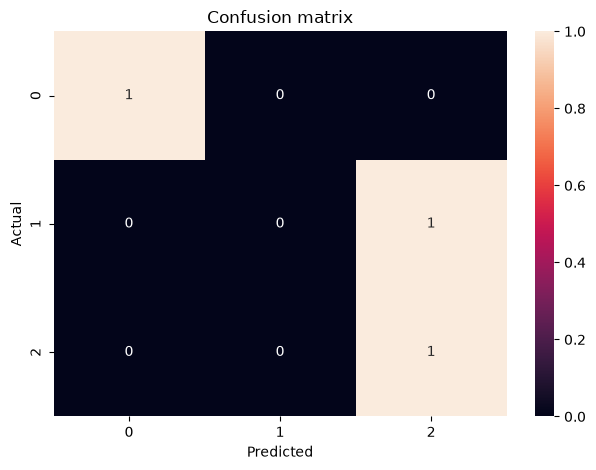

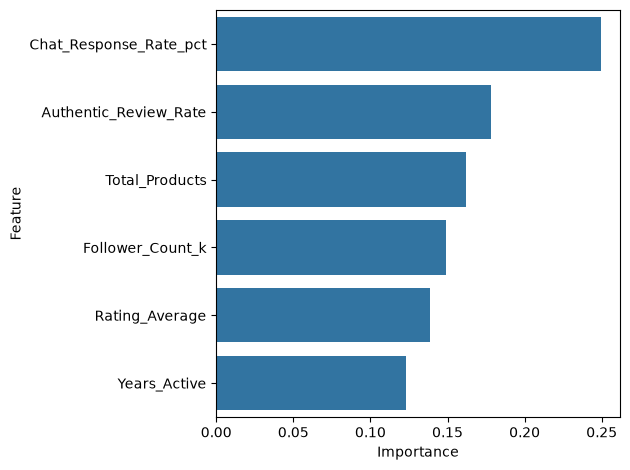

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



,input_fingerprint,label_mode,label_source,valid_ground_truth_evaluation,active_features,excluded_features,accuracy,baseline_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,target_accuracy,pass_accuracy_requirement
0,627926017fa4d7b3989d59d36d8011e24bec5fd3abc9e0...,pseudo,rule_based_pseudo_label,False,"[Years_Active, Total_Products, Follower_Count_...",[Conversion_Rate_pct],0.666667,0.333333,0.5,0.666667,0.555556,0.555556,0.75,False


,Feature,Importance
4,Chat_Response_Rate_pct,0.249391
5,Authentic_Review_Rate,0.178079
1,Total_Products,0.161862
2,Follower_Count_k,0.148969
3,Rating_Average,0.138528
0,Years_Active,0.123170


In [3]:
import joblib, matplotlib.pyplot as plt, seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

source = OUTPUT / "labeling" / "Data_Labeled.csv"
features = ["Years_Active","Total_Products","Follower_Count_k","Rating_Average","Chat_Response_Rate_pct","Authentic_Review_Rate","Conversion_Rate_pct"]
required_review = ["Labeler","Label_Reason","Review_Status"]
label_mode = CONFIG["classification"].get("label_mode", "manual")
label_source = "human_reviewed"
reasons = []
data = pd.DataFrame()
if label_mode == "pseudo":
    label_source = "rule_based_pseudo_label"
    data = pd.read_csv(OUTPUT / "labeling" / "Data_To_Label.csv")
    score_spec = {
        "Rating_Average": .30,
        "Chat_Response_Rate_pct": .25,
        "Authentic_Review_Rate": .20,
        "Follower_Count_k": .15,
        "Sales": .10,
    }
    score_parts = []
    used_weights = []
    from sklearn.preprocessing import MinMaxScaler
    for column, weight in score_spec.items():
        values = pd.to_numeric(data.get(column), errors="coerce")
        if values.notna().any() and values.nunique(dropna=True) >= 2:
            values = values.fillna(values.median())
            if column in {"Follower_Count_k", "Sales"}: values = np.log1p(values.clip(lower=0))
            score_parts.append(MinMaxScaler().fit_transform(values.to_frame()).ravel() * weight)
            used_weights.append(weight)
    if not score_parts:
        reasons.append("No usable fields are available to create pseudo-label proposals")
    else:
        data["Auto_Label_Score"] = np.sum(score_parts, axis=0) / sum(used_weights)
        data["Target_Label"] = pd.qcut(data["Auto_Label_Score"].rank(method="first"), q=3, labels=[0,1,2]).astype(int)
        data["Labeler"] = "AUTO_RULE"
        data["Label_Reason"] = data.apply(lambda row: f"Rule-based pseudo-label; score={row['Auto_Label_Score']:.4f}", axis=1)
        data["Review_Status"] = "pseudo"
        data.to_csv(OUTPUT / "labeling" / "Data_Label_Proposals.csv", index=False, encoding="utf-8-sig")
        print("PSEUDO-LABEL MODE: proposals are not human ground truth and model metrics are not independent validation.")
elif not source.exists():
    reasons.append("Save the reviewed Data_To_Label.csv as output/labeling/Data_Labeled.csv")
else:
    data = pd.read_csv(source)
    required_columns = {"Shop_ID","Target_Label",*required_review}
    missing_columns = required_columns - set(data)
    if missing_columns: reasons.append(f"Missing columns: {sorted(missing_columns)}")
    else:
        numeric_labels = pd.to_numeric(data["Target_Label"], errors="coerce")
        data = data.loc[numeric_labels.notna()].copy()
        if data.empty:
            reasons.append("Data_Labeled.csv has no labeled rows; assign Target_Label 0, 1 or 2")
        else:
            data["Target_Label"] = numeric_labels.loc[data.index].astype(int)
            if not set(data["Target_Label"]) <= {0,1,2}: reasons.append("Target_Label must contain only 0, 1 or 2")
            approved = data["Review_Status"].fillna("").astype(str).str.strip().str.lower().eq("approved")
            documented = data[["Labeler","Label_Reason"]].fillna("").astype(str).apply(lambda s:s.str.strip().ne("")).all(axis=1)
            if not (approved & documented).all(): reasons.append(f"{int((~(approved & documented)).sum())} labeled rows are not approved/documented")

if not data.empty and "Target_Label" in data and pd.to_numeric(data["Target_Label"], errors="coerce").notna().any():
    data["Target_Label"] = pd.to_numeric(data["Target_Label"], errors="coerce").astype(int)
    for feature in features:
        if feature not in data: data[feature] = np.nan
    feature_coverage = pd.DataFrame({
        "Feature":features,
        "Observed_Count":[pd.to_numeric(data[c],errors="coerce").notna().sum() for c in features],
        "Observed_Rate":[pd.to_numeric(data[c],errors="coerce").notna().mean() for c in features],
        "Unique_Observed_Values":[pd.to_numeric(data[c],errors="coerce").nunique(dropna=True) for c in features],
    })
    feature_coverage["Usable"] = (feature_coverage["Observed_Rate"] == 1.0) & (feature_coverage["Unique_Observed_Values"] >= 2)
    active_features = feature_coverage.loc[feature_coverage["Usable"],"Feature"].tolist()
    excluded_features = [c for c in features if c not in active_features]
    feature_coverage.to_csv(OUTPUT/"reports"/"classification_feature_coverage.csv",index=False)
    if not active_features: reasons.append("No model feature has complete observed values and variation")
    counts = data["Target_Label"].value_counts().reindex([0,1,2],fill_value=0)
    minimum = CONFIG["classification"]["minimum_shops_per_class"]
    if (counts < minimum).any(): reasons.append(f"Need at least {minimum} shops per class; found {counts.to_dict()}")

active_features = locals().get("active_features", [])
excluded_features = locals().get("excluded_features", features)
readiness = pd.DataFrame([{"ready":not reasons,"label_mode":label_mode,"label_source":label_source,"valid_ground_truth_evaluation":label_mode == "manual","labeled_rows":len(data),"active_features":", ".join(active_features),"excluded_features":", ".join(excluded_features),"blockers":" | ".join(reasons)}])
readiness.to_csv(OUTPUT/"reports"/"classification_readiness.csv",index=False)
display(readiness)

if reasons:
    print("CLASSIFICATION BLOCKED — no model or metrics were fabricated.")
    for reason in reasons: print("-",reason)
else:
    if excluded_features:
        print("EXPLORATORY FALLBACK: excluded unavailable/non-varying features:",excluded_features)
        print("This run is not submission-ready until the intended feature set is observed.")
    test_n = max(3,int(np.ceil(len(data)*CONFIG["classification"]["test_size"])))
    train,test = train_test_split(data,test_size=test_n,random_state=CONFIG["project"]["random_state"],stratify=data["Target_Label"])
    model = RandomForestClassifier(n_estimators=CONFIG["classification"]["n_estimators"],random_state=CONFIG["project"]["random_state"],class_weight="balanced").fit(train[active_features],train["Target_Label"])
    dummy = DummyClassifier(strategy="most_frequent").fit(train[active_features],train["Target_Label"])
    prediction = model.predict(test[active_features]); probability = model.predict_proba(test[active_features]).max(axis=1)
    macro = precision_recall_fscore_support(test["Target_Label"],prediction,average="macro",zero_division=0)
    metrics = {"input_fingerprint":INPUT_FINGERPRINT,"label_mode":label_mode,"label_source":label_source,"valid_ground_truth_evaluation":label_mode == "manual","active_features":active_features,"excluded_features":excluded_features,"accuracy":accuracy_score(test["Target_Label"],prediction),"baseline_accuracy":accuracy_score(test["Target_Label"],dummy.predict(test[active_features])),"macro_precision":macro[0],"macro_recall":macro[1],"macro_f1":macro[2],"weighted_f1":precision_recall_fscore_support(test["Target_Label"],prediction,average="weighted",zero_division=0)[2],"target_accuracy":CONFIG["classification"]["accuracy_target"]}
    metrics["pass_accuracy_requirement"] = metrics["accuracy"] > metrics["target_accuracy"]
    cm = confusion_matrix(test["Target_Label"],prediction,labels=[0,1,2])
    fig,ax=plt.subplots(); sns.heatmap(cm,annot=True,fmt="d",xticklabels=[0,1,2],yticklabels=[0,1,2],ax=ax); ax.set(xlabel="Predicted",ylabel="Actual",title="Confusion matrix"); fig.tight_layout(); fig.savefig(OUTPUT/"figures"/"confusion_matrix.png",dpi=160); plt.show(); plt.close(fig)
    importance = pd.DataFrame({"Feature":active_features,"Importance":model.feature_importances_}).sort_values("Importance",ascending=False)
    fig,ax=plt.subplots(); sns.barplot(data=importance,x="Importance",y="Feature",ax=ax); fig.tight_layout(); fig.savefig(OUTPUT/"figures"/"classification_feature_importance.png",dpi=160); plt.show(); plt.close(fig)
    result = pd.DataFrame({"Shop_ID":test["Shop_ID"],"Actual_Label":test["Target_Label"],"Predicted_Label":prediction,"Predicted_Probability":probability})
    result.to_csv(OUTPUT/"reports"/"Classification_Result.csv",index=False); importance.to_csv(OUTPUT/"reports"/"Classification_Feature_Importance.csv",index=False)
    (OUTPUT/"reports"/"classification_metrics.json").write_text(json.dumps(metrics,indent=2),encoding="utf-8")
    joblib.dump(model,OUTPUT/"models"/"random_forest_shop_reputation.joblib")
    print(classification_report(test["Target_Label"],prediction,labels=[0,1,2],zero_division=0)); display(pd.DataFrame([metrics])); display(importance)